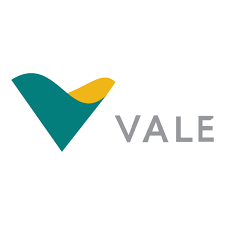

# PROGRAMA DESENVOLVER

## Perguntas Analíticas — Desafio Antecipação de Alertas Críticos

##### P1 — Pergunta Principal (Modelagem Preditiva)
**Quais equipamentos têm maior risco de gerar um alerta Don't Go nas próximas 4 horas, considerando o padrão atual de operação?**

---

### P2 — Perfil de Equipamentos (EDA)
**Qual é o perfil dos equipamentos que mais geram alertas Don't Go — considerando TAG, frota, modelo e horas de operação?**

---

### P3 — Padrões Temporais (EDA)
**Alertas críticos se concentram em determinados turnos, dias da semana ou períodos do mês?**

---

### P4 — Comportamento do Operador (EDA)
**O comportamento do operador tem correlação com a frequência de alertas Don't Go em um mesmo equipamento?**

---

### P5 — Impacto Operacional (Avaliação)
**Dado o risco previsto de alerta, qual seria a recomendação de ação: continuar operação, acionar manutenção preventiva agendada ou parada imediata?**

---

### P6 — Priorização da Manutenção (Resultados)
**Como priorizar a fila de inspeção da manutenção com base no score de risco de cada equipamento?**

In [1]:
%pip install pyarrow
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\lucas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
df_apontamentos = pd.read_parquet(r"projeto-desenvolver-vale\datasets\apontamentos\desenvolver_apontamentos.parquet", engine="fastparquet")

In [4]:
df_apontamentos.head()

,Id,Inicio,Fim,Tag,Frota,Tipo,Classe
0,23462554,2025-01-04 19:12:54,2025-01-04 19:40:29,CA65789,793-D 2S,Caminhao,Operando
1,23462555,2025-01-04 19:12:28,2025-01-04 19:38:15,CA65908,793-D 3S,Caminhao,Operando
2,23462556,2025-01-04 19:14:07,2025-01-04 19:18:29,CA65915,793-D 4S,Caminhao,Parado
3,23462759,2025-01-04 19:20:36,2025-01-04 19:27:44,CA5926,793-D 5S,Caminhao,Parado
4,23462762,2025-01-04 19:18:29,2025-01-04 19:23:51,CA65915,793-D 4S,Caminhao,Operando


In [5]:
df_telemetria_jan = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_jan.parquet", engine="fastparquet")

df_telemetria_fev = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_feb.parquet", engine="fastparquet")

df_telemetria_mar = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_mar.parquet", engine="fastparquet")

df_telemetria_abr = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_abr.parquet", engine="fastparquet")

df_telemetria_mai = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_may.parquet", engine="fastparquet")

df_telemetria_jun = pd.read_parquet(r"projeto-desenvolver-vale\datasets\telemetria\telemetry_jun.parquet", engine="fastparquet")

In [6]:
lista_dfs = [df_telemetria_jan, df_telemetria_fev, df_telemetria_mar, df_telemetria_abr, df_telemetria_mai, df_telemetria_jun]

In [7]:
df_telemetria_total = pd.concat(lista_dfs, ignore_index=True)

In [8]:
df_telemetria_total.head(5)

,Id_Eventos_Telemetria,Data_Evento,Inicio_Turno,Fim_Turno,Dia,Localidade,TAG,Tag_Frota,Tipo,Nome_Operador_Anon,Matricula_Operador_Hash,Id_Alarme,Alarme,Id_Criticidade,Criticidade,Valor,Classe,Is_Dont_Go
0,9372078,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609934,Rx Channel A Not Receiving Messages,3,Informacional,0,NULL,0
1,9372079,2025-01-01 00:00:14.553,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,335609935,Rx Channel B Not Receiving Messages,3,Informacional,0,NULL,0
2,9372097,2025-01-01 00:02:20.280,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"43,7999992370605",NULL,0
3,9372111,2025-01-01 00:02:59.077,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"74,7000045776367",NULL,0
4,9372120,2025-01-01 00:03:37.963,2024-12-31 18:00:00.000,2025-01-01 06:00:00.000,1,Itabira,CA5926,793-D 5S,Caminhao,OP_261,H_7d2a33163e23,84626976,Dipper,3,Informacional,"103,800003051758",NULL,0


In [9]:
df_telemetria_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37164054 entries, 0 to 37164053
Data columns (total 18 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   Id_Eventos_Telemetria    int64         
 1   Data_Evento              datetime64[us]
 2   Inicio_Turno             object        
 3   Fim_Turno                object        
 4   Dia                      int64         
 5   Localidade               object        
 6   TAG                      object        
 7   Tag_Frota                object        
 8   Tipo                     object        
 9   Nome_Operador_Anon       object        
 10  Matricula_Operador_Hash  object        
 11  Id_Alarme                int64         
 12  Alarme                   object        
 13  Id_Criticidade           int64         
 14  Criticidade              object        
 15  Valor                    object        
 16  Classe                   object        
 17  Is_Dont_Go               

In [12]:
apontamentos_vazios = "df_apontamentos"
if nome == "df_apontamentos":
    print("A string está vazia")

In [13]:
telemetria_vazios = "lista_dfs"
if nome == "lista_dfs":
    print("A string está vazia")

A string está vazia


In [14]:
print(df_apontamentos.isnull().sum())

Id        0
Inicio    0
Fim       0
Tag       0
Frota     0
Tipo      0
Classe    0
dtype: int64


In [18]:
print(df_telemetria_total.isnull().sum())

Id_Eventos_Telemetria      0
Data_Evento                0
Inicio_Turno               0
Fim_Turno                  0
Dia                        0
Localidade                 0
TAG                        0
Tag_Frota                  0
Tipo                       0
Nome_Operador_Anon         0
Matricula_Operador_Hash    0
Id_Alarme                  0
Alarme                     0
Id_Criticidade             0
Criticidade                0
Valor                      0
Classe                     0
Is_Dont_Go                 0
dtype: int64
